## 1. Setup Mount & Drive

In [1]:
from google.colab import drive
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Mount Drive
drive.mount('/content/drive')

# Konfigurasi Path
BASE_DIR = "/content/drive/MyDrive/skripsi/dataset/mbg"

# Folder Input (Tempat file-file pecahan berada)
DIR_MBG_RAW   = f"{BASE_DIR}/raw_data/mbg"
DIR_MAKAN_RAW = f"{BASE_DIR}/raw_data/makan_bergizi_gratis"

# Folder Output (Tempat menyimpan hasil gabungan)
DIR_OUTPUT    = f"{BASE_DIR}/merged_data"

# Buat folder output jika belum ada
os.makedirs(DIR_OUTPUT, exist_ok=True)

print(f"📂 Folder Input MBG   : {DIR_MBG_RAW}")
print(f"📂 Folder Input Makan : {DIR_MAKAN_RAW}")
print(f"📂 Folder Output      : {DIR_OUTPUT}")

Mounted at /content/drive
📂 Folder Input MBG   : /content/drive/MyDrive/skripsi/dataset/mbg/raw_data/mbg
📂 Folder Input Makan : /content/drive/MyDrive/skripsi/dataset/mbg/raw_data/makan_bergizi_gratis
📂 Folder Output      : /content/drive/MyDrive/skripsi/dataset/mbg/merged_data


## 2. Definisi Fungsi Preprocessing & Spam Filter

In [2]:
# [SETUP TIMEZONE]
START_DATE = pd.Timestamp("2025-01-06").tz_localize('UTC')
END_DATE   = pd.Timestamp("2026-01-07").tz_localize('UTC')

# --- SPAM KEYWORDS ---
spam_keywords = [
    # Judi Online
    "slot", "gacor", "zeus", "pragmatic", "maxwin", "wd", "depo",
    "pola gacor", "rtp", "judol", "link daftar", "situs",
    # E-Commerce & Spam Bot
    "shopee", "tokopedia", "lazada", "blibli", "cek keranjang",
    "spaylater", "dana kaget", "giveaway", "racun", "link di bio",
    "affiliate", "open joki", "joki tugas", "jasjok", "convert pulsa",
    "mutualan", "follback", "biro jodoh",
    # Konten Dewasa
    "open bo", "vcs", "video syur", "museum", "boke", "desah", "colmek"
]

def clean_for_deduplication_advanced(text):
    """
    Membersihkan teks secara agresif untuk menangkap duplikat 'tersembunyi'.
    Menghapus Link, Mention, Hashtag, dan Tanda Baca.
    """
    if not isinstance(text, str): return ""

    # 1. Lowercase
    t = text.lower()

    # 2. Hapus URL (http/https/www)
    t = re.sub(r'http\S+|www\S+|https\S+', '', t, flags=re.MULTILINE)

    # 3. Hapus Mention (@username)
    t = re.sub(r'@\w+', '', t)

    # 4. Hapus Hashtag (#tag) -> Agar "Info Mbg #seru" == "Info Mbg #mantap"
    t = re.sub(r'#\w+', '', t)

    # 5. Hapus Tanda Baca & Karakter Aneh (Hanya sisakan huruf & angka)
    t = re.sub(r'[^\w\s]', '', t)

    # 6. Hapus Spasi Berlebih & Trim
    t = re.sub(r'\s+', ' ', t).strip()

    return t

def is_spam(text):
    if not isinstance(text, str): return False
    return any(k in text.lower() for k in spam_keywords)

def has_required_keywords(text, required_list):
    if not isinstance(text, str): return False
    text_lower = text.lower()
    return any(k in text_lower for k in required_list)

def process_folder(folder_path, keyword_label, required_keywords):
    print(f"\n🚀 Memproses Folder: {keyword_label} ...")
    print(f"   🔑 Wajib mengandung: {required_keywords}")

    # 1. Baca File
    all_files = glob.glob(os.path.join(folder_path, "*.csv"))
    if not all_files:
        print(f"⚠️  Tidak ada file di {folder_path}")
        return pd.DataFrame()

    df_list = []
    for f in all_files:
        try:
            df = pd.read_csv(
                f,
                on_bad_lines='skip',
                lineterminator='\n',
                encoding_errors='ignore'
            )
            df_list.append(df)
        except Exception as e:
            print(f"   ❌ Gagal baca {os.path.basename(f)}: {e}")

    if not df_list: return pd.DataFrame()
    df_merged = pd.concat(df_list, ignore_index=True)
    init_count = len(df_merged)
    print(f"   📥 Total Raw Data    : {init_count} baris")
    print("   Min Date:", df_merged['created_at'].min())
    print("   Max Date:", df_merged['created_at'].max())

    # 2. Standarisasi Kolom
    col_map = {'date': 'created_at', 'text': 'full_text', 'id_str': 'id'}
    df_merged.rename(columns=col_map, inplace=True)

    if 'full_text' not in df_merged.columns or 'created_at' not in df_merged.columns:
        print("   ❌ Error: Kolom 'full_text' atau 'created_at' hilang.")
        return pd.DataFrame()

    # 3. STRICT KEYWORD VALIDATION
    mask_keyword = df_merged['full_text'].apply(lambda x: has_required_keywords(x, required_keywords))
    df_merged = df_merged[mask_keyword].copy()
    loss_keyword = init_count - len(df_merged)
    print(f"   🔍 Keyword Mismatch : {loss_keyword} baris dibuang (Tidak relevan)")

    # 4. Filter Rentang Tanggal
    df_merged['created_at'] = pd.to_datetime(df_merged['created_at'], errors='coerce', utc=True)
    df_merged = df_merged.dropna(subset=['created_at'])

    mask_date = (
        (df_merged['created_at'] >= START_DATE) &
        (df_merged['created_at'] < END_DATE)
    )
    out_of_range_count = len(df_merged) - mask_date.sum()
    df_merged = df_merged[mask_date].copy()
    print(f"   📅 Diluar Tanggal    : {out_of_range_count} baris dibuang")

    # 5. HAPUS DUPLIKAT (ADVANCED)
    # Kita buat kolom temporary yang sangat bersih
    df_merged['temp_dedup'] = df_merged['full_text'].apply(clean_for_deduplication_advanced)

    # Hapus jika temp_dedup menjadi kosong (berarti isinya cuma link/mention doang)
    df_merged = df_merged[df_merged['temp_dedup'] != '']

    current_len = len(df_merged)
    # Dedup berdasarkan teks yang sudah dibersihkan total
    df_merged.drop_duplicates(subset=['temp_dedup'], keep='first', inplace=True)

    print(f"   ♻️  Duplikat Dihapus  : {current_len - len(df_merged)} baris (Advanced Dedup)")

    # 6. Filter Spam
    df_merged['is_spam'] = df_merged['full_text'].apply(is_spam)
    spam_count = df_merged['is_spam'].sum()
    df_clean = df_merged[~df_merged['is_spam']].copy()
    print(f"   🗑️  Spam Dibuang      : {spam_count} baris")

    # 7. Finalisasi
    df_clean.sort_values(by='created_at', ascending=True, inplace=True)
    df_clean.drop(columns=['temp_dedup', 'is_spam'], inplace=True, errors='ignore')
    df_clean['source_keyword'] = keyword_label

    print(f"   ✨ DATA VALID AKHIR  : {len(df_clean)} baris")
    return df_clean

## 3. Eksekusi Penggabungan dan Penyimpanan

In [3]:
KEYWORDS_MAKAN = [
    "makan bergizi gratis",
    "makan bergizi",
    "makan siang gratis",
    "program makan gratis"
]

KEYWORDS_MBG = [
    "mbg"
]

# 1. Proses Data "Makan Bergizi Gratis"
df_makan = process_folder(DIR_MAKAN_RAW, "makan_bergizi_gratis", KEYWORDS_MAKAN)

# 2. Proses Data "MBG"
df_mbg = process_folder(DIR_MBG_RAW, "mbg", KEYWORDS_MBG)

# Simpan Hasil
output_makan = f"{DIR_OUTPUT}/merged_makan_bergizi_gratis.csv"
output_mbg   = f"{DIR_OUTPUT}/merged_mbg.csv"

if not df_makan.empty:
    df_makan.to_csv(output_makan, index=False)
    print(f"\n💾 Tersimpan: {output_makan}")

if not df_mbg.empty:
    df_mbg.to_csv(output_mbg, index=False)
    print(f"💾 Tersimpan: {output_mbg}")


🚀 Memproses Folder: makan_bergizi_gratis ...
   🔑 Wajib mengandung: ['makan bergizi gratis', 'makan bergizi', 'makan siang gratis', 'program makan gratis']
   📥 Total Raw Data    : 70075 baris
   Min Date: 2025-01-06T08:21:42.000Z
   Max Date: 2026-01-06T23:51:37.000Z
   🔍 Keyword Mismatch : 4998 baris dibuang (Tidak relevan)
   📅 Diluar Tanggal    : 0 baris dibuang
   ♻️  Duplikat Dihapus  : 19709 baris (Advanced Dedup)
   🗑️  Spam Dibuang      : 3435 baris
   ✨ DATA VALID AKHIR  : 41933 baris

🚀 Memproses Folder: mbg ...
   🔑 Wajib mengandung: ['mbg']
   📥 Total Raw Data    : 101934 baris
   Min Date: 2024-12-30T03:24:38.000Z
   Max Date: Wed Sep 17 23:59:20 +0000 2025
   🔍 Keyword Mismatch : 5375 baris dibuang (Tidak relevan)


/tmp/ipykernel_14544/3030950097.py:100: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_merged['created_at'] = pd.to_datetime(df_merged['created_at'], errors='coerce', utc=True)


   📅 Diluar Tanggal    : 234 baris dibuang
   ♻️  Duplikat Dihapus  : 7556 baris (Advanced Dedup)
   🗑️  Spam Dibuang      : 8082 baris
   ✨ DATA VALID AKHIR  : 80687 baris

💾 Tersimpan: /content/drive/MyDrive/skripsi/dataset/mbg/merged_data/merged_makan_bergizi_gratis.csv
💾 Tersimpan: /content/drive/MyDrive/skripsi/dataset/mbg/merged_data/merged_mbg.csv


## 4. Visualisasi (Chart by Day & Month)

In [4]:
import matplotlib.dates as mdates

def plot_timeline(df_list, labels):
    plt.figure(figsize=(15, 6))

    for df, label in zip(df_list, labels):
        if df.empty: continue
        # Resample Harian
        daily = df.set_index('created_at').resample('D').size()
        plt.plot(daily.index, daily.values, label=f"{label} (Daily)", alpha=0.8)

    # Format Sumbu X Harian (Biar rapi)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
    plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=14)) # Label tiap 2 minggu

    plt.title("Tren Jumlah Tweet Harian (Daily Volume)")
    plt.xlabel("Tanggal")
    plt.ylabel("Jumlah Tweet")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_monthly(df_list, labels):
    # Gabungkan data dulu untuk plotting
    combined_monthly = pd.DataFrame()

    for df, label in zip(df_list, labels):
        if df.empty: continue
        # Resample Bulanan ('ME' = Month End, pengganti 'M' di pandas baru)
        # Gunakan 'M' jika pandas lama, 'ME' jika pandas baru. 'M' biasanya aman.
        try:
            monthly = df.set_index('created_at').resample('ME').size()
        except:
            monthly = df.set_index('created_at').resample('M').size()

        combined_monthly[label] = monthly

    if combined_monthly.empty:
        print("⚠️ Tidak ada data untuk grafik bulanan.")
        return

    # Ini mengubah label sumbu X dari datetime UTC yang panjang menjadi format ringkas
    combined_monthly.index = combined_monthly.index.strftime('%b %y')

    # Plot Bar Chart
    ax = combined_monthly.plot(kind='bar', figsize=(12, 6), width=0.8, alpha=0.85)

    plt.title("Tren Jumlah Tweet Bulanan (Monthly Volume)")
    plt.xlabel("Bulan")
    plt.ylabel("Jumlah Tweet")
    plt.xticks(rotation=0) # Biar label tidak miring
    plt.grid(axis='y', alpha=0.3)
    plt.legend()

    # Tambahkan label angka di atas batang
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontsize=9)

    plt.tight_layout()
    plt.show()


📊 Menampilkan Grafik Tren Harian...


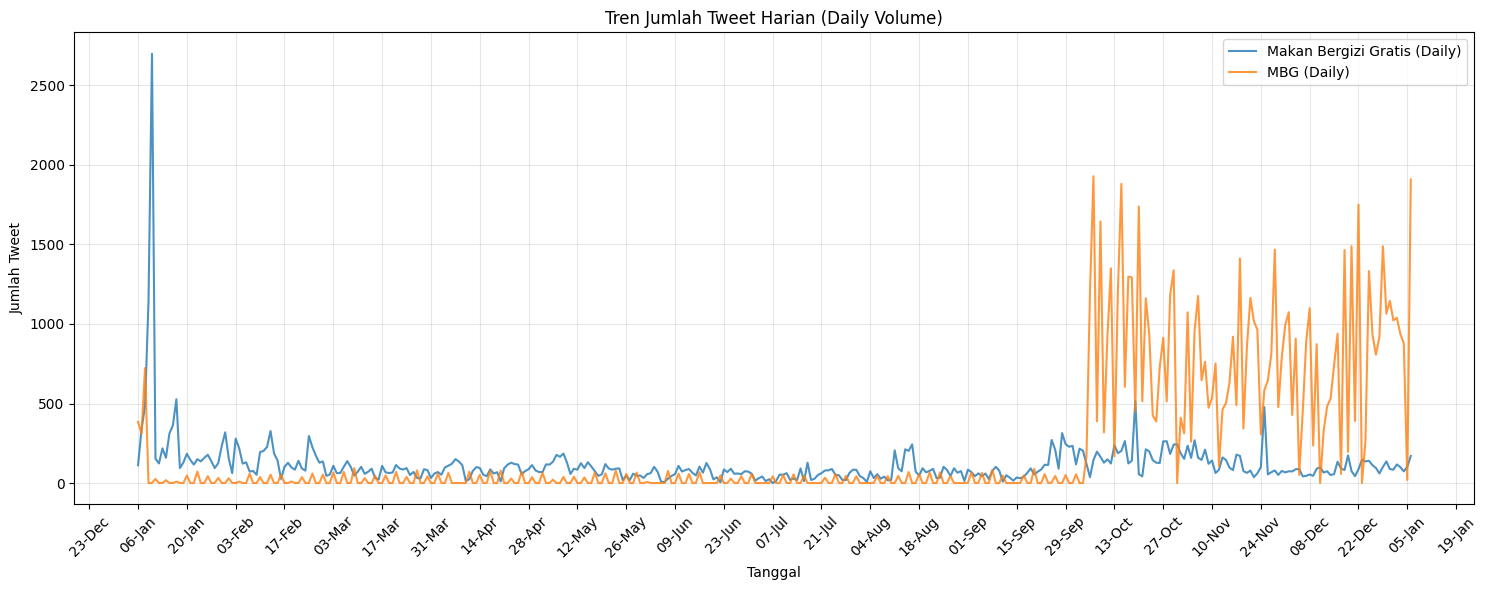

In [5]:
# Eksekusi Grafik Tren Harian
print("\n📊 Menampilkan Grafik Tren Harian...")
plot_timeline([df_makan, df_mbg], ["Makan Bergizi Gratis", "MBG"])


📊 Menampilkan Grafik Tren Bulanan...


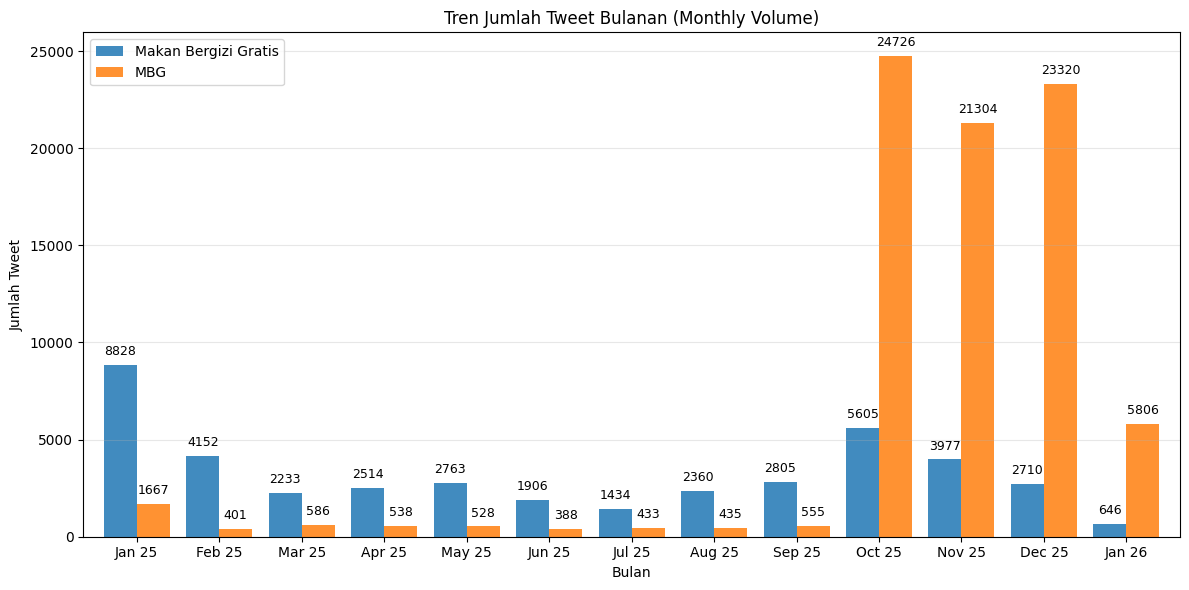

In [6]:
# Eksekusi Grafik Tren Bulanan
print("\n📊 Menampilkan Grafik Tren Bulanan...")
plot_monthly([df_makan, df_mbg], ["Makan Bergizi Gratis", "MBG"])